# Chapter 08 이미지를 위한 인공 신경망
## 08-2 합성곱 신경망을 사용한 이미지 분류
### 패션 MNIST 데이터 불러오기
* 완전 연결 신경망에서는 입력 이미지를 밀집층에 연결하기 위해 일렬로 펼쳐야 함. 이 작업을 위해 넘파이 `reshape()` 메서드를 사용하거나 Flatten 클래스를 사용했음. 합성곱 신경망은 2차원 이미지를 그대로 사용하기 때문에 이렇게 일렬로 펼치지 않음.
* 다만 8장 1절에서 언급했듯이 입력 이미지는 항상 깊이(채널) 차원이 있어야 함. 흑백 이미지의 경우 채널 차원이 없는 2차원 배열이지만 Conv2D 층을 사용하기 위해 마지막에 이 채널 차원을 추가해야 함.

In [4]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


* 이제 (48000, 28, 28) 크기인 train_input이 (48000, 28, 28, 1) 크기인 train_scaled가 되었음.

### 합성곱 신경망 만들기


In [5]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.add(keras.layers.MaxPooling2D(2))

* 패션 MNIST 이미지가 (28, 28) 크기에 세임 패딩을 적용했기 때문에 합성곱 층에서 출력된 특성 맵의 가로세로 크기는 입력과 동일. 그다음 (2, 2) 풀링을 적용했으므로 특성 맵의 크기는 절반으로 줄어듦. 합성곱 층에서 32개의 필터를 사용했기 때문에 이 특성 맵의 깊이는 32가 됨. 따라서 최대 풀링을 통과한 특성 맵의 크기는 (14, 14, 32)가 될 것.

In [7]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

* 첫번째 합성곱-풀링 층과 마찬가지로 이 합성곱 층은 세임 패딩을 사용함. 따라서 입력의 가로세로 크기를 줄이지 않음. 이어지는 풀링 층에서 이 크기를 절반으로 줄임. 64개의 필터를 사용했으므로 최종적으로 만들어지는 특성 맵의 크기는 (7, 7, 64)가 될 것.
* 이제 이 3차원 특성 맵을 일렬로 펼칠 차례. 이렇게 하는 이유는 마지막에 10개의 뉴런을 가진 (밀집) 출력층에서 확률을 계산하기 때문. 여기에서는 특성 맵을 일렬로 펼쳐서 바로 출력층에 전달하지 않고 중간에 하나의 밀집 은닉층을 하나 더 두도록 하겠음.

In [8]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

* 은닉층과 출력층 사이에 드롭아웃을 넣었음. 드롭아웃 층이 은닉층의 과대적합을 막아 성능을 조금 더 개선해 줄 것.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

* 첫 번째 합성곱 층은 32개의 필터를 가지고 있고 크기가 (3, 3), 깊이가 1. 또 필터마다 하나의 절편이 있음. 따라서 총 3 $\times$ 3 $\times$ 1 $\times$ 32 + 32 = 320개의 파라미터가 있음.
* 두 번째 합성곱 층은 64개의 필터를 사용하고 크기가 (3, 3), 깊이가 32. 역시 필터마다 하나의 절편이 있음. 따라서 총 3 $\times$ 3 $\times$ 32 $\times$ 64 + 64 = 18,496개의 파라미터가 있음. 층의 구조를 잘 이해하고 있는지 확인하려면 이렇게 모델 파라미터 개수를 계산해 볼 것.

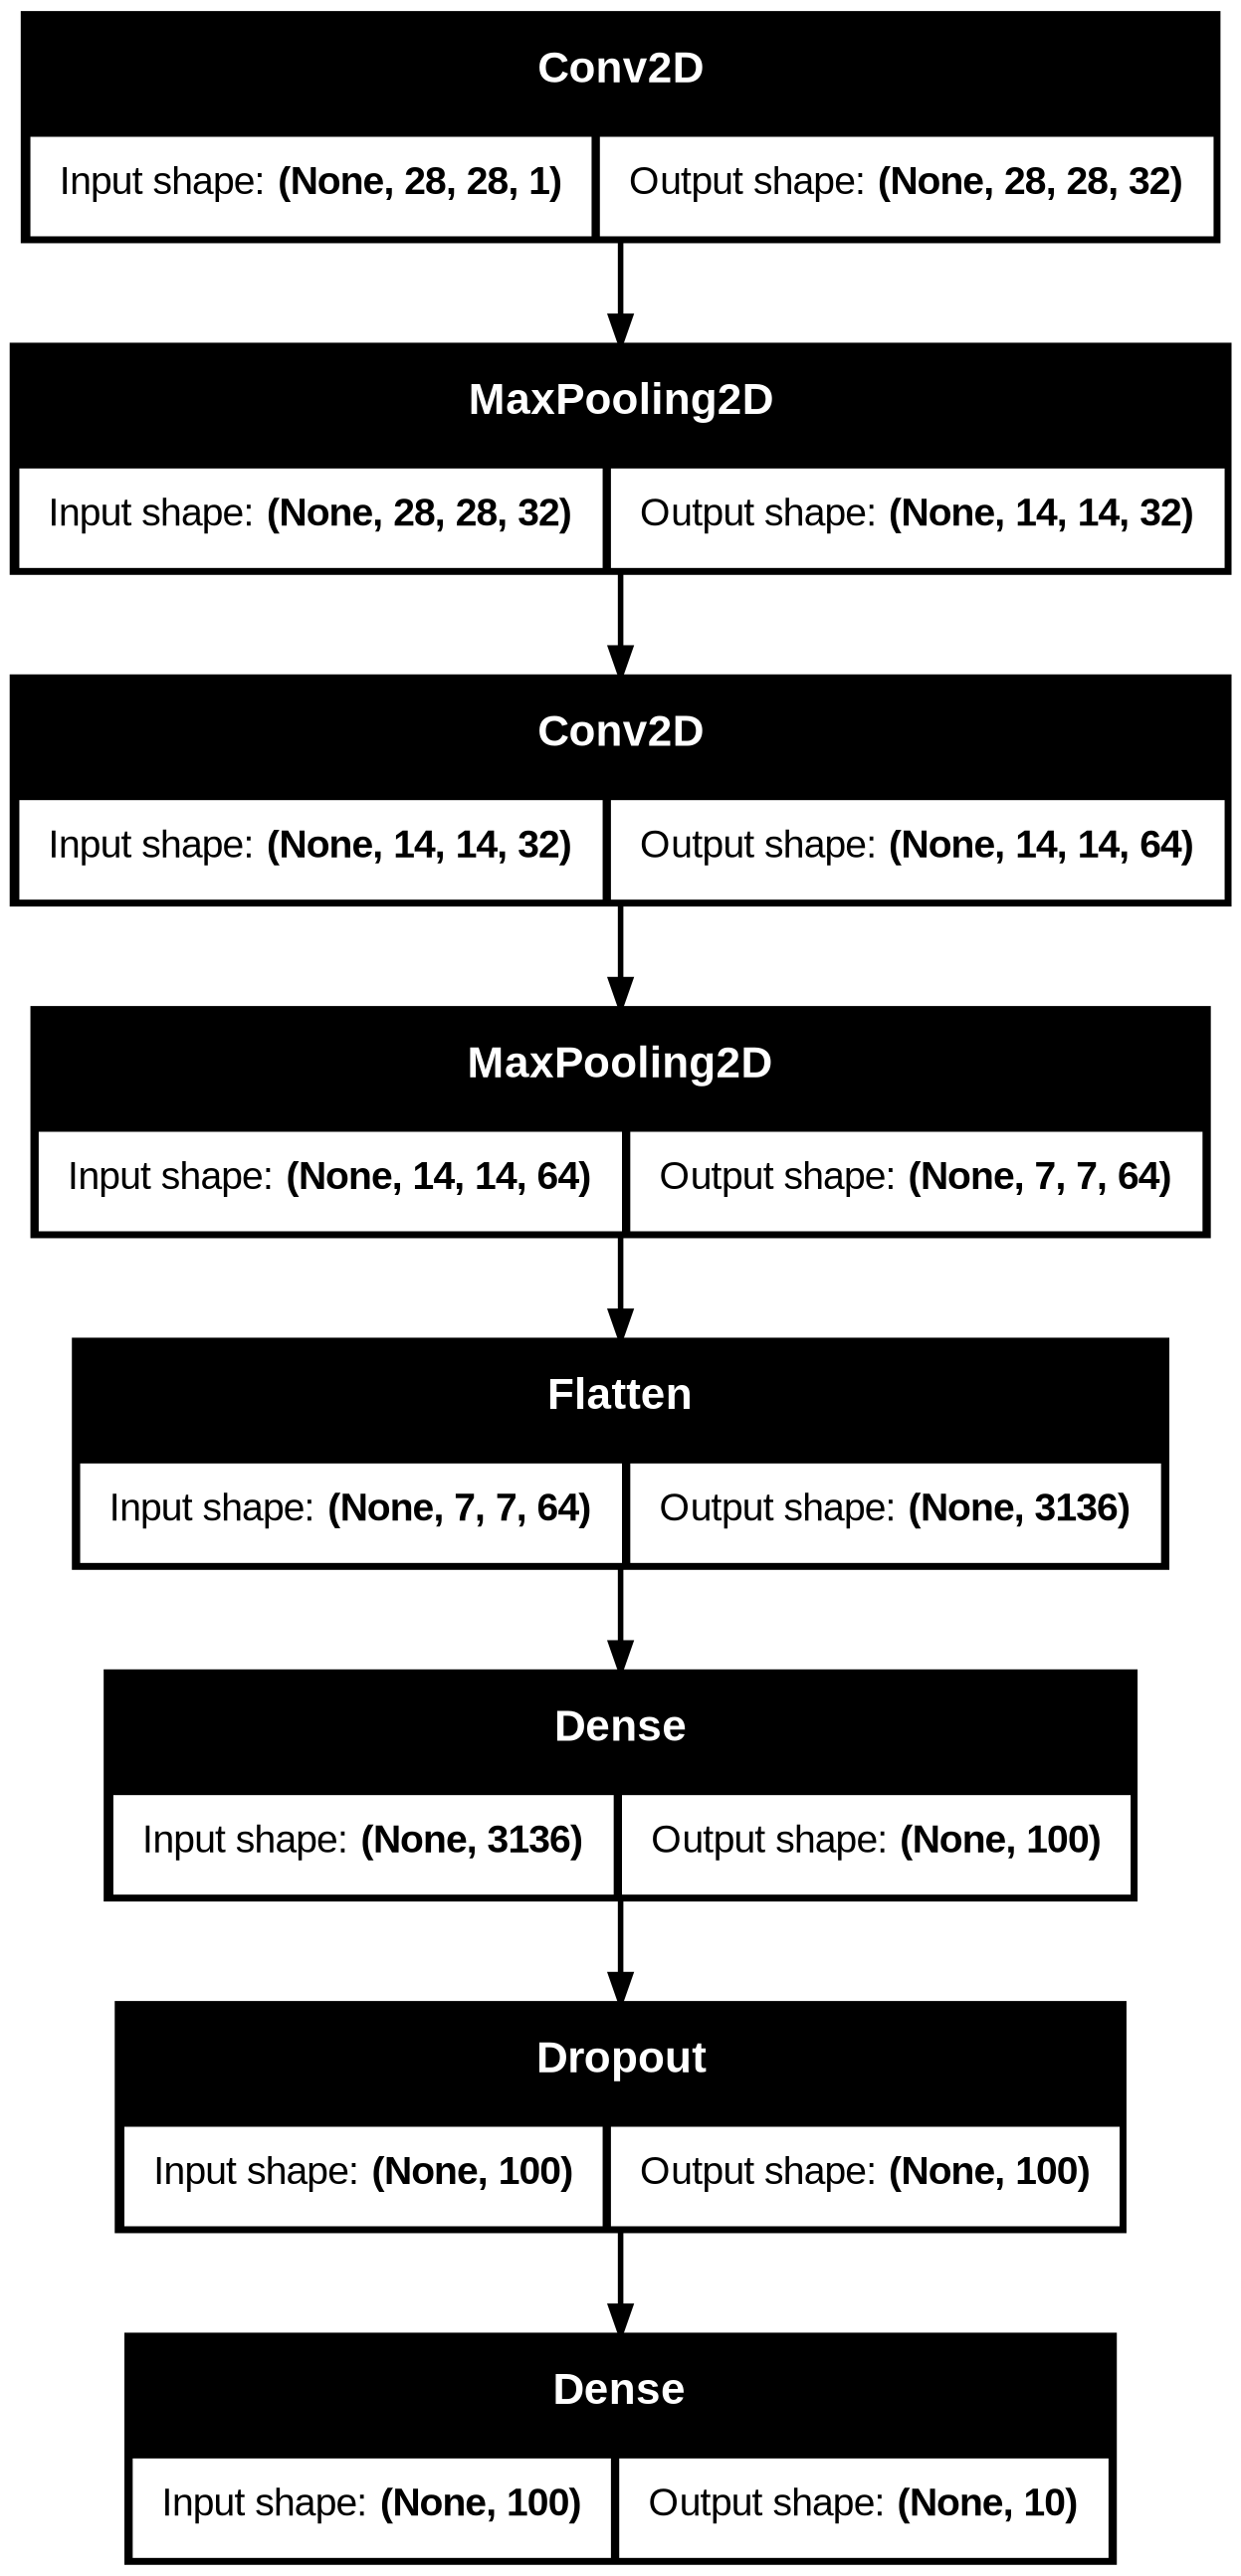

In [10]:
keras.utils.plot_model(model, show_shapes=True)

### 모델 컴파일과 훈련

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1486/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7265 - loss: 0.7534

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8021 - loss: 0.5491 - val_accuracy: 0.8783 - val_loss: 0.3362
Epoch 2/20
1495/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8643 - loss: 0.3817

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8705 - loss: 0.3634 - val_accuracy: 0.8942 - val_loss: 0.2891
Epoch 3/20
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8846 - loss: 0.3195

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8903 - loss: 0.3106 - val_accuracy: 0.8994 - val_loss: 0.2677
Epoch 4/20
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9017 - loss: 0.2757

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9011 - loss: 0.2761 - val_accuracy: 0.9142 - val_loss: 0.2409
Epoch 5/20
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9081 - loss: 0.2459

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9101 - loss: 0.2473 - val_accuracy: 0.9130 - val_loss: 0.2407
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9166 - loss: 0.2297 - val_accuracy: 0.9147 - val_loss: 0.2428
Epoch 7/20
1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9244 - loss: 0.2069

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9220 - loss: 0.2121 - val_accuracy: 0.9205 - val_loss: 0.2187
Epoch 8/20
1489/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9298 - loss: 0.1920

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9281 - loss: 0.1956 - val_accuracy: 0.9208 - val_loss: 0.2173
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9327 - loss: 0.1812 - val_accuracy: 0.9186 - val_loss: 0.2342
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9353 - loss: 0.1718 - val_accuracy: 0.9216 - val_loss: 0.2294


* 얼핏 보아도 훈련 세트의 정확도가 이전보다 훨씬 좋아진 것을 알 수 있음.

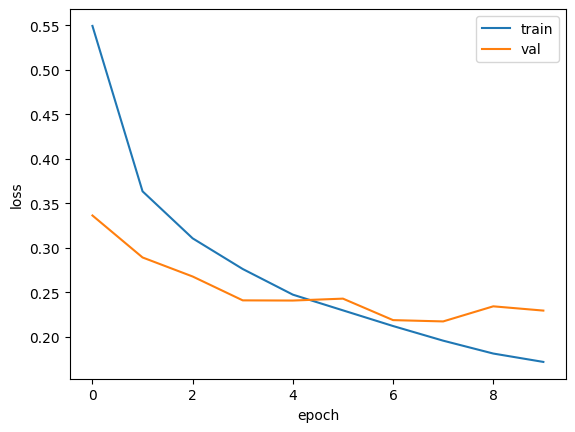

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 검증 세트에 대한 손실이 점차 감소하다가 정체되기 시작하고 훈련 세트에 대한 손실은 점점 더 낮아지고 있음. 이 그래프를 기반으로 아홉 번째 에포크를 최적으로 생각할 수 있음.

In [13]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9208 - loss: 0.2173


[0.21725904941558838, 0.9208333492279053]

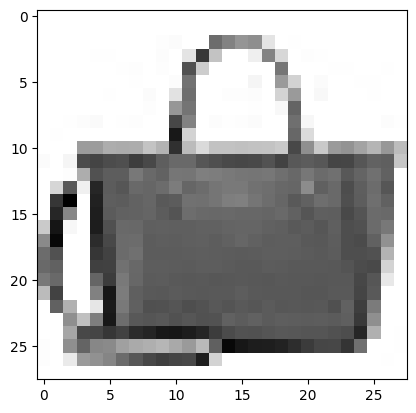

In [14]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [15]:
preds = model.predict(val_scaled[0:1])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
[[6.5860352e-17 1.7288551e-21 9.1314762e-22 8.2939482e-19 7.9251978e-19
  6.2629267e-16 5.8227990e-20 2.1593388e-15 1.0000000e+00 1.5860776e-18]]


> 왜 슬라이싱을 사용했나요?
> * 케라스의 fit(), predict(), evaluate() 메서드는 모두 입력의 첫 번째 차원이 배치 차원일 것으로 기대함. 따라서 샘플 하나를 전달할 때 (28, 28, 1)이 아니라 (1, 28, 28, 1) 크기를 전달해야 함. 배열 슬라이싱은 인덱싱과 다르게 선택된 원소가 하나이더라도 전체 차원이 유지되어 (1, 28, 28, 1) 크기를 만듦.

* 출력 결과를 보면 아홉 번째 값이 1이고 다른 값은 거의 0에 가까움. 다시 말해 아홉 번째 클래스라고 강하게 주장.

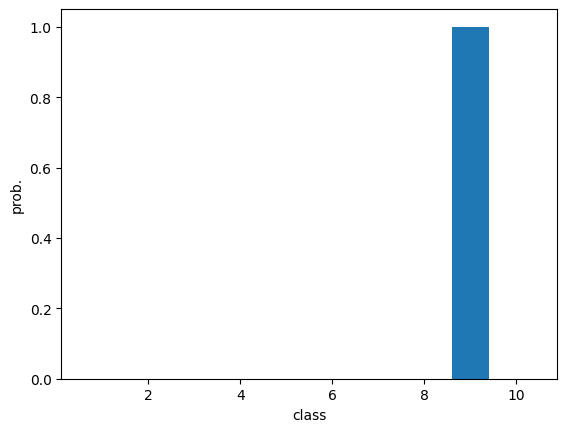

In [16]:
plt.bar(range(1, 11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [17]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [18]:
import numpy as np
print(classes[np.argmax(preds)])

가방


In [19]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [20]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9141 - loss: 0.2413


[0.24132636189460754, 0.9140999913215637]

* 역시 예상대로 테스트 세트에서의 점수는 검증 세트보다 조금 더 작음. 이 모델을 실전에 투입하여 패션 아이템을 분류한다면 약 91%의 성능을 기대할 수 있겠음!